# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


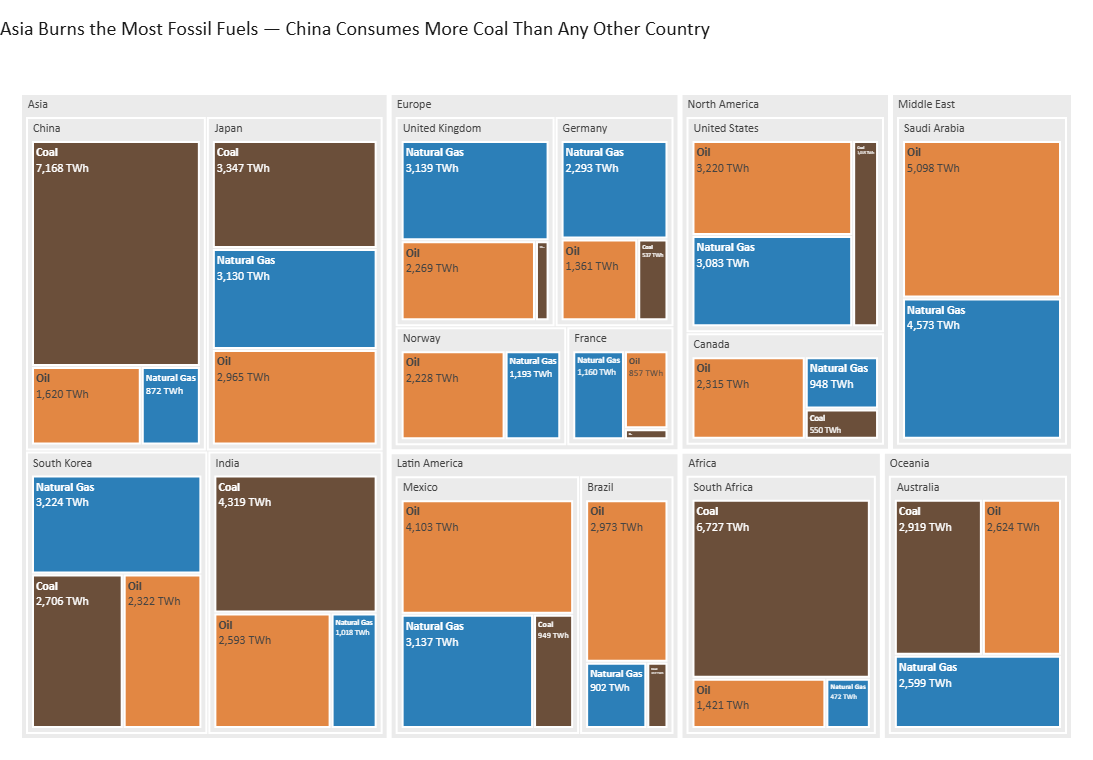

In [9]:

# TASK 1 — Treemap: Fossil Fuel Dependency by Country

# Filter fossil fuels only
fossil = df.loc[df['Source_Type'] == 'Fossil'].copy()

COAL_COLOR  = '#6B4F3A'   # softened brown
OIL_COLOR   = '#E28743'   # medium-orange
GAS_COLOR   = '#2C7FB8'   # professional blue

PARENT_GREY = '#EBEBEB'

fossil_color_map = {
    'Coal': COAL_COLOR,
    'Oil': OIL_COLOR,
    'Natural Gas': GAS_COLOR,
}

fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_color_map,
    height=760,
)

leaf_colors = set(fossil_color_map.values())

node_colors = list(fig.data[0].marker.colors)

fig.data[0].marker.colors = [
    c if c in leaf_colors else PARENT_GREY
    for c in node_colors
]

fig.update_traces(

    texttemplate='<b>%{label}</b><br>%{value:,.0f} TWh',

    textfont=dict(
        family='Calibri',
        size=12
    ),

    marker=dict(
        line=dict(
            color='white',
            width=2
        )
    ),

    hovertemplate=(
        '<b>%{label}</b><br>'
        '%{value:,.0f} TWh'
        '<extra></extra>'
    ),
)

fig.update_layout(

    title=dict(
        text=(
            'Asia Burns the Most Fossil Fuels — '
            'China Consumes More Coal Than Any Other Country'
        ),

        font=dict(
            family='Calibri',
            size=20,
            color='#1A1A1A'
        ),

        x=0,
        xanchor='left'
    ),

    font=dict(
        family='Calibri',
        size=12,
        color='#1A1A1A'
    ),

    margin=dict(
        l=15,
        r=15,
        t=70,
        b=15
    ),

    paper_bgcolor='white',
)

fig.show()

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


Total spend by day (verify insight title):
day
Sat     1778.40
Sun     1627.16
Thur    1096.33
Fri      325.88
Name: Total_Bill, dtype: float64

Top 8 groups:
     day    time smoker  Total_Bill
6    Sun  Dinner     No     1168.88
5    Sat  Dinner    Yes      893.62
4    Sat  Dinner     No      884.78
9   Thur   Lunch     No      751.31
7    Sun  Dinner    Yes      458.28
10  Thur   Lunch    Yes      326.24
1    Fri  Dinner    Yes      178.26
3    Fri   Lunch    Yes       73.94


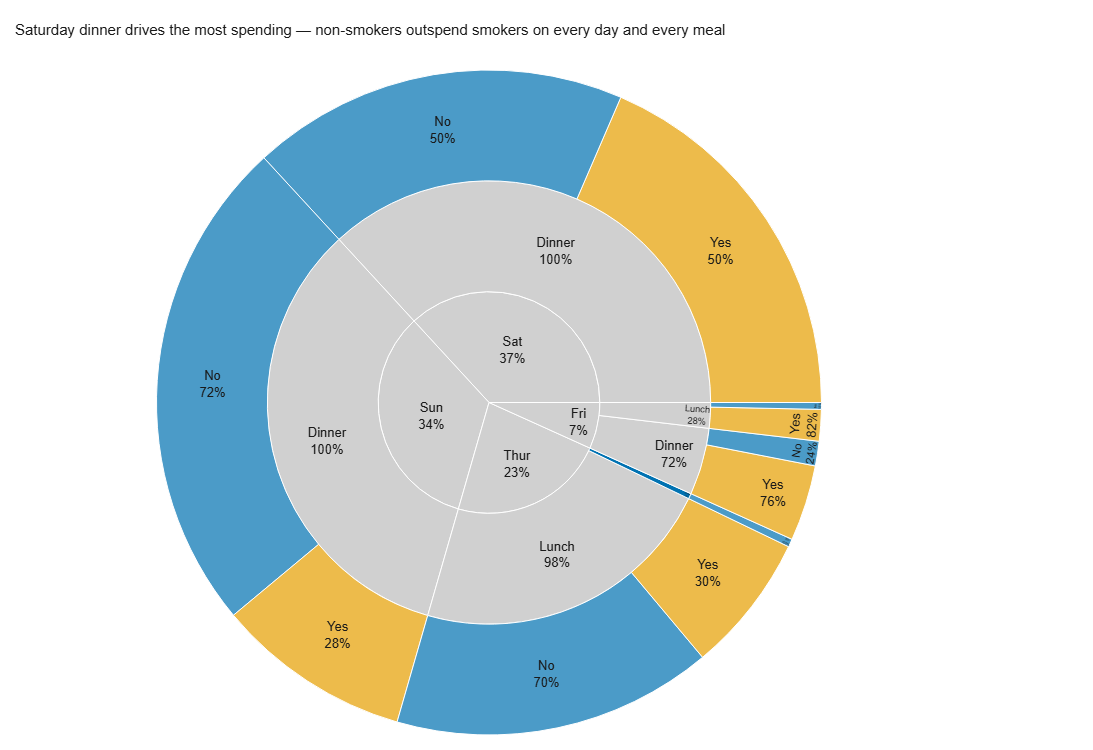

In [10]:
# Task 2
# YOUR CODE HERE

tips = px.data.tips()

df_sun = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
    .rename(columns={'total_bill': 'Total_Bill'})
)

print("Total spend by day (verify insight title):")
print(df_sun.groupby('day')['Total_Bill'].sum().sort_values(ascending=False))
print()
print("Top 8 groups:")
print(df_sun.sort_values('Total_Bill', ascending=False).head(8))
NONSMOKER_BLUE = '#0072B2'   # deep blue  
SMOKER_AMBER   = '#E69F00'   # amber/gold 
PARENT_GREY    = '#D0D0D0'   # light grey 

smoker_color_map = {
    'No':  NONSMOKER_BLUE,
    'Yes': SMOKER_AMBER,
}

# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.sunburst(
    df_sun,
    path=['day', 'time', 'smoker'],
    values='Total_Bill',
    color='smoker',
    color_discrete_map=smoker_color_map,
    labels={'Total_Bill': 'Total Bill ($)', 'smoker': 'Smoker?'},
    height=750,
    width=1000,   
)

# ── Step 2: Text labels ───────────────────────────────────────────────────────

fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='auto',
    textfont=dict(family='Arial', size=13, color='#1A1A1A'),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Total Bill: $%{value:,.2f}<br>'
        '%{percentParent:.0%} of %{parent}'
        '<extra></extra>'
    ),
)

leaf_colors = set(smoker_color_map.values())
fig.data[0].marker.colors = [
    c if c in leaf_colors else PARENT_GREY
    for c in fig.data[0].marker.colors
]

fig.update_layout(
    title=dict(
        text=(
            'Saturday dinner drives the most spending — '
            'non-smokers outspend smokers on every day and every meal'
        ),
        font=dict(
            family='Arial',
            size=15,         
            color='#1A1A1A',
        ),
        x=0,
        xanchor='left',
        pad=dict(l=15),
    ),
    font=dict(family='Arial', size=13, color='#1A1A1A'),
    margin=dict(l=15, r=130, t=70, b=15),
    paper_bgcolor='white',
    legend=dict(
        title=dict(
            text='Smoker?',
            font=dict(size=13, family='Arial', color='#1A1A1A')
        ),
        orientation='v',
        x=1.02,
        y=0.5,
        font=dict(size=12, family='Arial', color='#1A1A1A'),
        bgcolor='white',
        bordercolor='#DDDDDD',
        borderwidth=1,
    ),
)

fig.show()


## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


Countries: 14
           Country     TWh
4           France  7593.0
9           Norway  6174.0
2           Canada  5969.0
1           Brazil  4975.0
11     South Korea  2484.0
6            India  1336.0
13   United States  1137.0
7            Japan  1012.0
12  United Kingdom   993.0
5          Germany   929.0


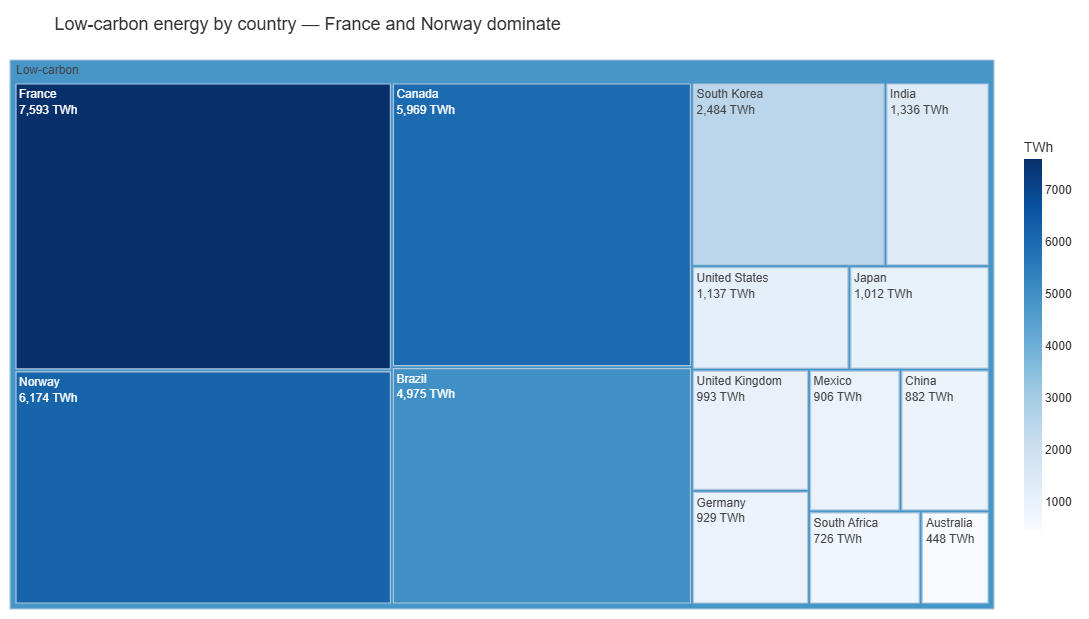

In [16]:
import plotly.express as px

# Task 3 — Treemap vs Bar: Low-carbon energy by country

# -----------------------------------
# 1) Filter and aggregate the data
# -----------------------------------
lowcarbon = (
    df.loc[df["Source_Type"] == "Low-carbon", ["Country", "TWh"]]
    .groupby("Country", as_index=False)["TWh"]
    .sum()
    .sort_values("TWh", ascending=False)
)

print(f"Countries: {len(lowcarbon)}")
print(lowcarbon.head(10))

lowcarbon["All"] = "Low-carbon"



top_country = lowcarbon.iloc[0]["Country"]

# -----------------------------------
# 2) Treemap
# -----------------------------------
fig_tree = px.treemap(
    lowcarbon,
    path=["All", "Country"],
    values="TWh",
    color="TWh",
    color_continuous_scale="Blues",
    title="Low-carbon energy by country — France and Norway dominate",
    height=600,
    width=1100
)

fig_tree.update_traces(
    texttemplate="%{label}<br>%{value:,.0f} TWh",
    hovertemplate="<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>",
    root_color="white",
    marker=dict(line=dict(color="#AFC6DD", width=1.2))
)

fig_tree.update_layout(
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial", size=12, color="#2F2F2F"),
    title_font=dict(family="Arial", size=18, color="#2F2F2F"),
    margin=dict(l=10, r=10, t=60, b=10),
    coloraxis_colorbar=dict(
        title=dict(text="TWh"),
        tickfont=dict(color="#2F2F2F"),
        thickness=18,
        len=0.75
    )
)

fig_tree.show()



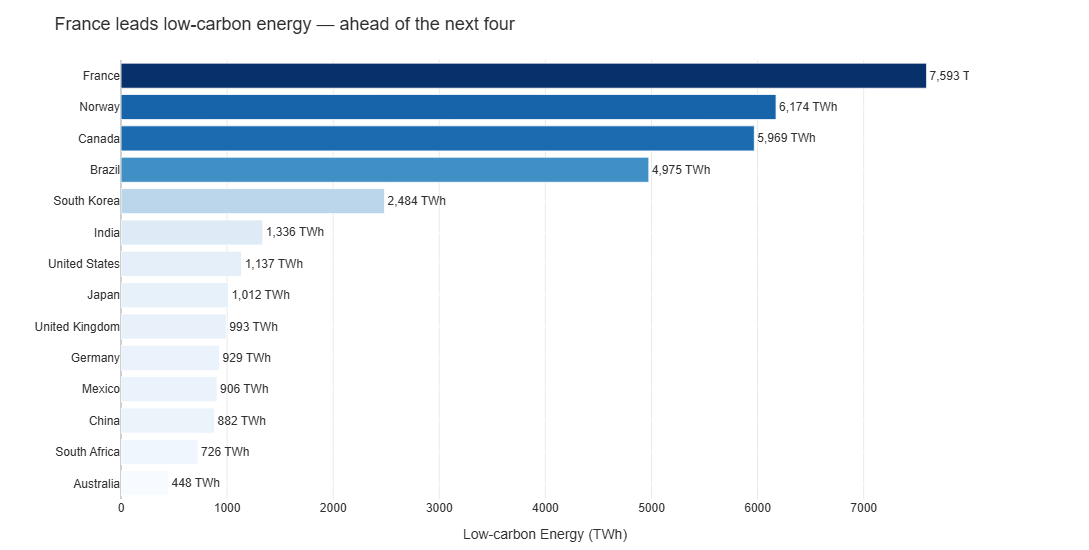

In [17]:
# Horizontal Bar

lowcarbon_sorted = lowcarbon.sort_values("TWh", ascending=True)

fig_bar = px.bar(
    lowcarbon_sorted,
    x="TWh",
    y="Country",
    orientation="h",
    color="TWh",
    color_continuous_scale="Blues",
    title=f"{top_country} leads low-carbon energy — ahead of the next four",
    height=550,
    width=950
)

fig_bar.update_traces(
    texttemplate="%{x:,.0f} TWh",
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>%{x:,.0f} TWh<extra></extra>",
    marker=dict(line=dict(color="white", width=0.8))
)

fig_bar.update_layout(
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial", size=12, color="#2F2F2F"),
    title_font=dict(family="Arial", size=18, color="#2F2F2F"),
    margin=dict(l=10, r=120, t=60, b=40),
    coloraxis_showscale=False,
    xaxis=dict(
        title="Low-carbon Energy (TWh)",
        gridcolor="#EAEAEA",
        zeroline=True,
        zerolinecolor="#CFCFCF",
        rangemode="tozero"
    ),
    yaxis=dict(
        title="",
        gridcolor="white"
    )
)

fig_bar.show()

## Which chart is better — and why?

#### The horizontal bar chart is better for this data, because it shows the ranking of countries more clearly and makes comparison easier.

* The treemap shows area, which is harder to compare precisely — it is useful when there are 15+ categories and the relative sizes (shares) matter more than the rank order. With a moderate number of countries and a clear "France leads" story, the bar chart communicates the gap far more directly.

* Final Recommendation: Use the bar chart. The treemap is visually interesting but sacrifices precision for aesthetics in this case.